In [1]:
import sys
sys.path.append("..")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from torchsummary import summary

from utils.train_model import train_model
from utils.handling_data import summarize_diagnostics, imshow


cudnn.benchmark = True
plt.ion()   # interactive mode

In [2]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [3]:
data_dir = "../data/cifake-real-and-ai-generated-synthetic-images"
image_datasets_logreg = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                                 data_transforms[x]
                                                 ) for x in ['train', 'test']}
# В документации написано, что если юзаешь CUDA, то необходимо выставлять pin_memory=True. Якобы так быстрее.
# https://pytorch.org/docs/stable/data.html
dataloaders_logreg = {x: torch.utils.data.DataLoader(image_datasets_logreg[x], 
													 batch_size=512,
													 shuffle=True, 
													 num_workers=0, 
													 pin_memory=True)
                for x in ['train', 'test']}
dataset_sizes = {x: len(image_datasets_logreg[x]) for x in ['train', 'test']}
class_names = image_datasets_logreg['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device!")

Using cuda:0 device!


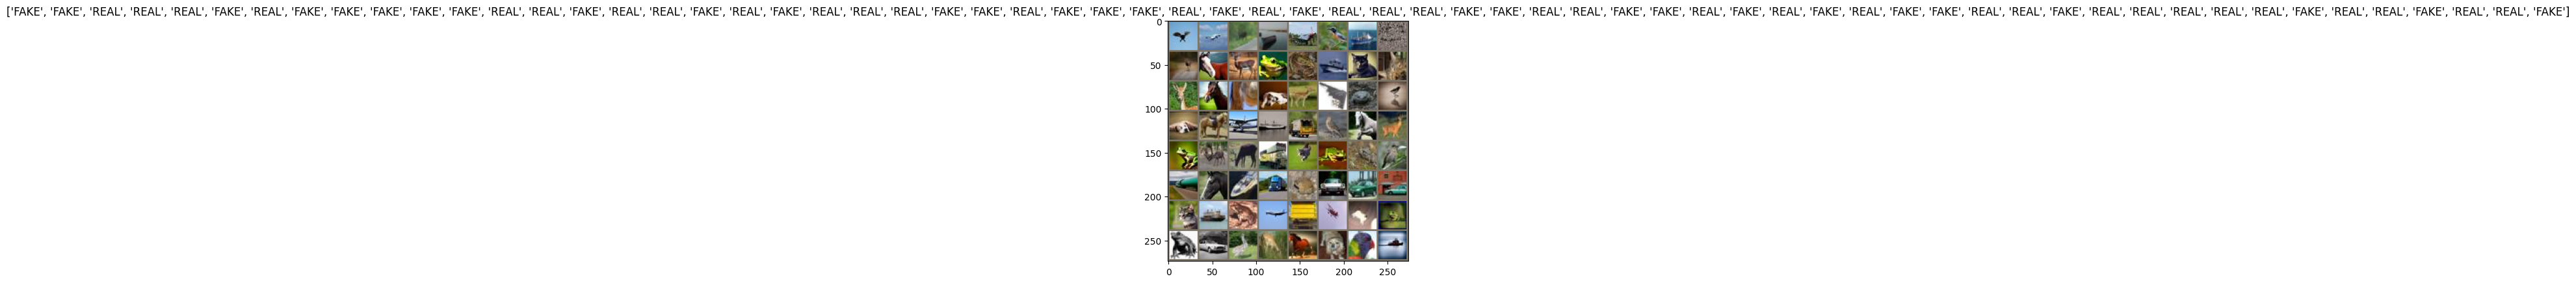

In [4]:
# отдельный DATALOADER для отрисовки, чтобы было удобнее
dataloaders_show = {x: torch.utils.data.DataLoader(image_datasets_logreg[x], batch_size=64,
                                                   shuffle=True, num_workers=0, pin_memory=True)
                                                   for x in ['train', 'test']}

# Get a batch of training data
inputs, classes = next(iter(dataloaders_show['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

[Отличное объяснение того, в чем разница между transfer_learning и fine_tuning](https://cs231n.github.io/transfer-learning/).

# ResNet18 + LogReg

Epoch 0/14
----------
train Loss: 0.5137 Acc: 0.7359
test Loss: 0.4962 Acc: 0.7439

Epoch 1/14
----------
train Loss: 0.4934 Acc: 0.7562
test Loss: 0.5039 Acc: 0.7272

Epoch 2/14
----------
train Loss: 0.4919 Acc: 0.7570
test Loss: 0.4974 Acc: 0.7361

Epoch 3/14
----------
train Loss: 0.4880 Acc: 0.7601
test Loss: 0.4892 Acc: 0.7675

Epoch 4/14
----------
train Loss: 0.4901 Acc: 0.7585
test Loss: 0.4894 Acc: 0.7481

Epoch 5/14
----------
train Loss: 0.4908 Acc: 0.7562
test Loss: 0.4862 Acc: 0.7591

Epoch 6/14
----------
train Loss: 0.4904 Acc: 0.7592
test Loss: 0.5073 Acc: 0.7207

Epoch 7/14
----------
train Loss: 0.4816 Acc: 0.7630
test Loss: 0.4838 Acc: 0.7612

Epoch 8/14
----------
train Loss: 0.4805 Acc: 0.7639
test Loss: 0.4832 Acc: 0.7642

Epoch 9/14
----------
train Loss: 0.4806 Acc: 0.7647
test Loss: 0.4832 Acc: 0.7656

Epoch 10/14
----------
train Loss: 0.4787 Acc: 0.7647
test Loss: 0.4834 Acc: 0.7667

Epoch 11/14
----------
train Loss: 0.4793 Acc: 0.7639
test Loss: 0.4842 Acc

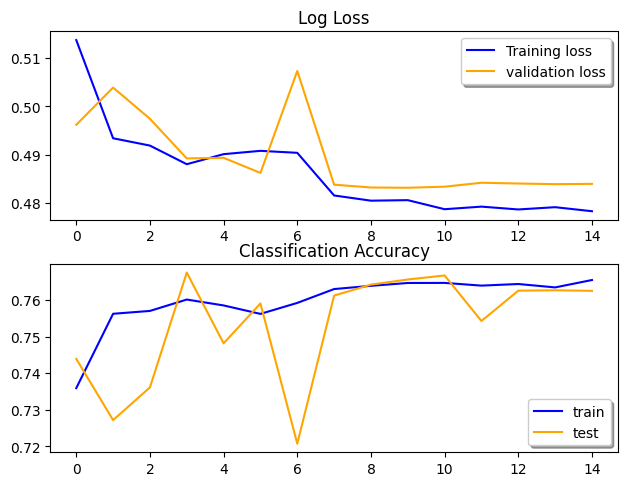

In [5]:
model_logreg = models.resnet18(weights='IMAGENET1K_V1')
# Фиксируем все параметры нейронной сети. Будем настраивать параметры только в fc-слое
for param in model_logreg.parameters():
    param.requires_grad = False

num_ftrs = model_logreg.fc.in_features
# Признаки, извлеченные из сверточных слоев пускаем на вход линейной модели
# nn.Sequential(nn.Linear(num_ftrs, 1), nn.Sigmoid()) - это равносильно sigmoid(x), где x - линейная комбинация признаков
# На выходе мы получаем вероятность принадлежности объекта к классу REAL (поскольку LABEL(REAL) == 1)
model_logreg.fc = nn.Sequential(nn.Linear(num_ftrs, 1), nn.Sigmoid())
model_logreg = model_logreg.cuda()

# BCELoss - это обычный logloss. CrossEntropy для логистической регрессии использовать некорректно
criterion_logreg = torch.nn.BCELoss()

# Меняем параметры только для fc-слоя
optimizer_logreg = optim.SGD(model_logreg.fc.parameters(), lr=0.01, momentum=0.9, weight_decay=0.01)

# Итеративное изменение градиентного шага. Прикольная вещь. Чем дольше мы обучаемся, тем по идее мы должны быть ближе к минимуму.
# А чем ближе к минимуму, тем меньший размер шагов мы должны делать, чтобы его случайно не перескочить и сойтись в нем.
# Итеративное изменения шага помогает это сделать
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_logreg, step_size=7, gamma=0.1)
# Обучаем модель
model_inf_logreg, dict_stat = train_model(model=model_logreg, 
                                          criterion=criterion_logreg, 
                                          optimizer=optimizer_logreg, 
                                          scheduler=exp_lr_scheduler, 
                                          dataset_sizes=dataset_sizes,
                                          dataloaders=dataloaders_logreg, 
                                          num_epochs=15,
                                          isLogreg=True,
                                          isSVM=False)
summarize_diagnostics(dict_stat, title='ResNet18(Conv) + LogReg')

# ResNet18 + SVM

Epoch 0/14
----------
train Loss: 0.6061 Acc: 0.3714
test Loss: 0.5834 Acc: 0.3229

Epoch 1/14
----------
train Loss: 0.5603 Acc: 0.3797
test Loss: 0.5525 Acc: 0.3749

Epoch 2/14
----------
train Loss: 0.5544 Acc: 0.3814
test Loss: 0.5523 Acc: 0.3940

Epoch 3/14
----------
train Loss: 0.5538 Acc: 0.3825
test Loss: 0.5609 Acc: 0.4084

Epoch 4/14
----------
train Loss: 0.5509 Acc: 0.3816
test Loss: 0.5502 Acc: 0.3882

Epoch 5/14
----------
train Loss: 0.5521 Acc: 0.3821
test Loss: 0.5538 Acc: 0.3971

Epoch 6/14
----------
train Loss: 0.5528 Acc: 0.3815
test Loss: 0.5780 Acc: 0.4234

Epoch 7/14
----------
train Loss: 0.5413 Acc: 0.3860
test Loss: 0.5493 Acc: 0.3719

Epoch 8/14
----------
train Loss: 0.5393 Acc: 0.3845
test Loss: 0.5497 Acc: 0.3882

Epoch 9/14
----------
train Loss: 0.5393 Acc: 0.3850
test Loss: 0.5488 Acc: 0.3785

Epoch 10/14
----------
train Loss: 0.5392 Acc: 0.3836
test Loss: 0.5474 Acc: 0.3861

Epoch 11/14
----------
train Loss: 0.5399 Acc: 0.3846
test Loss: 0.5486 Acc

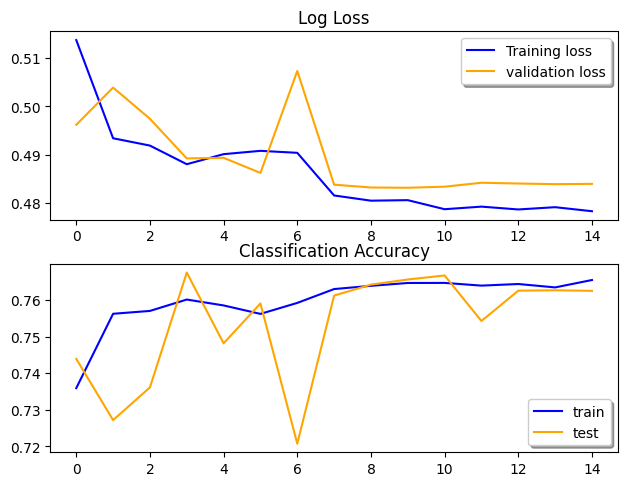

In [6]:
class TargetMapper:
    def __init__(self, labels):
        self.labels_dict = {v: -1 if v=='REAL' else 1 for k, v in enumerate(labels)}
        self.labels_list = sorted(labels)

    def __call__(self, target):
        return self.labels_dict[self.labels_list[target]]
image_datasets_svm = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                              data_transforms[x],
                                              target_transform=TargetMapper(["REAL", "FAKE"]) # Трансформируем значения меток классов для SVM
                                              ) for x in ['train', 'test']}
# В документации написано, что если юзаешь CUDA, то необходимо выставлять pin_memory=True. Якобы так быстрее.
# https://pytorch.org/docs/stable/data.html
dataloaders_svm = {x: torch.utils.data.DataLoader(image_datasets_svm[x], batch_size=512,
                                                  shuffle=True, num_workers=0, pin_memory=True)
                for x in ['train', 'test']}
dataset_sizes = {x: len(image_datasets_svm[x]) for x in ['train', 'test']}
class_names = image_datasets_svm['train'].classes
model_svm = models.resnet18(weights='IMAGENET1K_V1')
# Фиксируем все параметры нейронной сети. Будем настраивать параметры только в fc-слое
for param in model_svm.parameters():
    param.requires_grad = False

num_ftrs = model_svm.fc.in_features
# Признаки, извлеченные из сверточных слоев пускаем на вход линейной модели
model_svm.fc = nn.Sequential(nn.Linear(num_ftrs, 1))
model_svm = model_svm.cuda()

# HingeEmbeddingLoss - это LOSS используемый для SVM
criterion_svm = torch.nn.HingeEmbeddingLoss()

# Меняем параметры только для fc-слоя
optimizer_svm = optim.SGD(model_svm.fc.parameters(), lr=0.01, momentum=0.7, weight_decay=0.01)

# Итеративное изменение градиентного шага. Прикольная вещь. Чем дольше мы обучаемся, тем по идее мы должны быть ближе к минимуму.
# А чем ближе к минимуму, тем меньший размер шагов мы должны делать, чтобы его случайно не перескочить и сойтись в нем.
# Итеративное изменения шага помогает это сделать
exp_lr_scheduler_svm = lr_scheduler.StepLR(optimizer_svm, step_size=7, gamma=0.1)
# Обучаем модель
model_inf_svm, dict_stat_svm = train_model(model_svm, 
                                           criterion_svm, 
                                           optimizer_svm, 
                                           exp_lr_scheduler_svm, 
										   dataset_sizes=dataset_sizes,
                                           dataloaders=dataloaders_svm, 
                                           num_epochs=15,
										   isLogreg=False,
                                           isSVM=True)
summarize_diagnostics(dict_stat, title='ResNet18(Conv) + SVM')

# ResNet18. Fine-tuning.

In [7]:
model_resnet18 = models.resnet18(weights='IMAGENET1K_V1')
# Разморозим все параметры нейронной сети. Будем настраивать всю сеть целиком
for param in model_resnet18.parameters():
    param.requires_grad = True

model_resnet18 = model_resnet18.cuda()

criterion_resnet18 = torch.nn.CrossEntropyLoss()

# Меняем параметры всей нейронной сети
optimizer_resnet18 = optim.SGD(model_resnet18.parameters(), lr=0.01, momentum=0.9, weight_decay=0.01)

# Итеративное изменение градиентного шага. Прикольная вещь. Чем дольше мы обучаемся, тем по идее мы должны быть ближе к минимуму.
# А чем ближе к минимуму, тем меньший размер шагов мы должны делать, чтобы его случайно не перескочить и сойтись в нем.
# Итеративное изменения шага помогает это сделать
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_resnet18, step_size=7, gamma=0.1)

In [8]:
# Обучаем модель
model_inf_logreg, dict_stat = train_model(model=model_resnet18, 
                                          criterion=criterion_resnet18, 
                                          optimizer=optimizer_resnet18, 
                                          scheduler=exp_lr_scheduler, 
                                          dataset_sizes=dataset_sizes,
                                          dataloaders=dataloaders_logreg, 
                                          num_epochs=15,
                                          isLogreg=False,
                                          isSVM=False,
										  isNN=True)

Epoch 0/14
----------
train Loss: 0.3543 Acc: 0.9011
test Loss: 0.1417 Acc: 0.9459

Epoch 1/14
----------
train Loss: 0.1049 Acc: 0.9607
test Loss: 0.1344 Acc: 0.9491

Epoch 2/14
----------
train Loss: 0.0775 Acc: 0.9711
test Loss: 0.1609 Acc: 0.9402

Epoch 3/14
----------
train Loss: 0.0668 Acc: 0.9757
test Loss: 0.1375 Acc: 0.9499

Epoch 4/14
----------
train Loss: 0.0656 Acc: 0.9763
test Loss: 0.1333 Acc: 0.9526

Epoch 5/14
----------
train Loss: 0.0665 Acc: 0.9764
test Loss: 0.1239 Acc: 0.9572

Epoch 6/14
----------
train Loss: 0.0759 Acc: 0.9734
test Loss: 0.1646 Acc: 0.9474

Epoch 7/14
----------
train Loss: 0.0340 Acc: 0.9900
test Loss: 0.0820 Acc: 0.9748

Epoch 8/14
----------
train Loss: 0.0157 Acc: 0.9966
test Loss: 0.0879 Acc: 0.9764

Epoch 9/14
----------
train Loss: 0.0102 Acc: 0.9985
test Loss: 0.0981 Acc: 0.9762

Epoch 10/14
----------
train Loss: 0.0083 Acc: 0.9991
test Loss: 0.1048 Acc: 0.9756

Epoch 11/14
----------
train Loss: 0.0075 Acc: 0.9994
test Loss: 0.1118 Acc

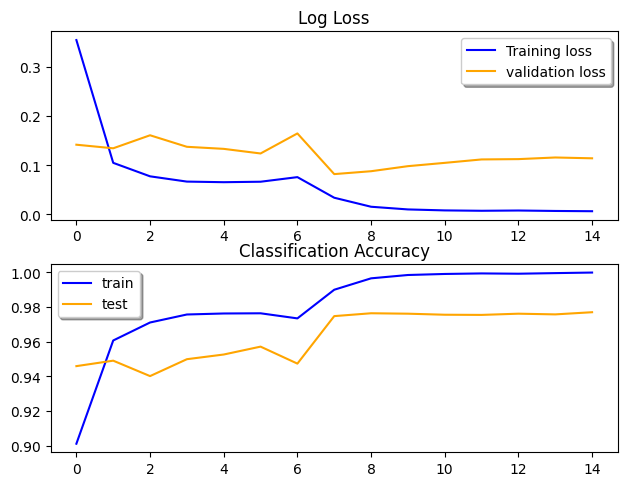

In [9]:
summarize_diagnostics(dict_stat, title='ResNet18(FC)')

Полный список претрейн моделей, доступных для трансфера из PyTorch: https://pytorch.org/vision/main/models.html

# ResNet50. Fine-tuning.

Epoch 0/14
----------


train Loss: 0.3179 Acc: 0.9182
test Loss: 0.1343 Acc: 0.9500

Epoch 1/14
----------
train Loss: 0.0796 Acc: 0.9700
test Loss: 0.1723 Acc: 0.9344

Epoch 2/14
----------
train Loss: 0.0562 Acc: 0.9787
test Loss: 0.2676 Acc: 0.8996

Epoch 3/14
----------
train Loss: 0.0535 Acc: 0.9798
test Loss: 0.1152 Acc: 0.9572

Epoch 4/14
----------
train Loss: 0.0531 Acc: 0.9808
test Loss: 0.1672 Acc: 0.9447

Epoch 5/14
----------
train Loss: 0.0593 Acc: 0.9791
test Loss: 0.1903 Acc: 0.9425

Epoch 6/14
----------
train Loss: 0.0704 Acc: 0.9751
test Loss: 0.1867 Acc: 0.9334

Epoch 7/14
----------
train Loss: 0.0281 Acc: 0.9915
test Loss: 0.0764 Acc: 0.9770

Epoch 8/14
----------
train Loss: 0.0105 Acc: 0.9979
test Loss: 0.0917 Acc: 0.9767

Epoch 9/14
----------
train Loss: 0.0079 Acc: 0.9986
test Loss: 0.0983 Acc: 0.9773

Epoch 10/14
----------
train Loss: 0.0076 Acc: 0.9988
test Loss: 0.1017 Acc: 0.9770

Epoch 11/14
----------
train Loss: 0.0070 Acc: 0.9991
test Loss: 0.1064 Acc: 0.9775

Epoch 12/14


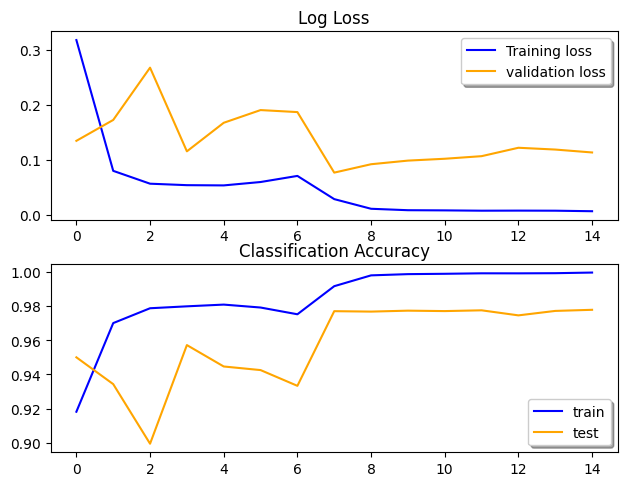

In [10]:
model_resnet18 = models.resnet50(weights='IMAGENET1K_V1')
# Разморозим все параметры нейронной сети. Будем настраивать всю сеть целиком
for param in model_resnet18.parameters():
    param.requires_grad = True

model_resnet18 = model_resnet18.cuda()

criterion_resnet18 = torch.nn.CrossEntropyLoss()

# Меняем параметры всей нейронной сети
optimizer_resnet18 = optim.SGD(model_resnet18.parameters(), lr=0.01, momentum=0.9, weight_decay=0.01)

# Итеративное изменение градиентного шага. Прикольная вещь. Чем дольше мы обучаемся, тем по идее мы должны быть ближе к минимуму.
# А чем ближе к минимуму, тем меньший размер шагов мы должны делать, чтобы его случайно не перескочить и сойтись в нем.
# Итеративное изменения шага помогает это сделать
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_resnet18, step_size=7, gamma=0.1)
# Обучаем модель
model_inf_logreg, dict_stat = train_model(model=model_resnet18, 
                                          criterion=criterion_resnet18, 
                                          optimizer=optimizer_resnet18, 
                                          scheduler=exp_lr_scheduler, 
                                          dataset_sizes=dataset_sizes,
                                          dataloaders=dataloaders_logreg, 
                                          num_epochs=15,
                                          isLogreg=False,
                                          isSVM=False,
										  isNN=True)
summarize_diagnostics(dict_stat, title='ResNet50(FC)')